In [5]:
import pandas as pd

df = pd.read_csv("../data/creditcard.csv")

In [6]:
df.shape


(284807, 31)

In [7]:
df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [8]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [10]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [11]:
df.duplicated().sum()

1081

In [12]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [13]:
df["Class"].value_counts(normalize=True) * 100

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

In [14]:
df[["Time", "Amount"]].describe()

,Time,Amount
count,284807.000000,284807.000000
mean,94813.859575,88.349619
std,47488.145955,250.120109
min,0.000000,0.000000
25%,54201.500000,5.600000
50%,84692.000000,22.000000
75%,139320.500000,77.165000
max,172792.000000,25691.160000


In [15]:
#DROP DUPLICATES

In [16]:
df = df.drop_duplicates()
print(df.shape)
print(df["Class"].value_counts())

(283726, 31)
Class
0    283253
1       473
Name: count, dtype: int64


In [17]:
df["Amount"]                  # one column
df[["Time", "Amount"]]        # several columns 

,Time,Amount
0,0.0,149.62
1,0.0,2.69
2,1.0,378.66
3,1.0,123.50
4,2.0,69.99
...,...,...
284802,172786.0,0.77
284803,172787.0,24.79
284804,172788.0,67.88
284805,172788.0,10.00


In [18]:
#filtering 
fraud = df[df["Class"] == 1]
normal = df[df["Class"] == 0]

print(fraud.shape)
print(normal.shape)

(473, 31)
(283253, 31)


In [19]:
big_fraud = df[(df["Class"] == 1) & (df["Amount"] > 500)]
print(len(big_fraud))

34


In [20]:
fraud_zero = df[(df["Class"] == 1) & (df["Amount"] == 0)]
print(len(fraud_zero))

25


In [21]:
df.groupby("Class")["Amount"].mean()

Class
0     88.413575
1    123.871860
Name: Amount, dtype: float64

In [22]:
df.groupby("Class")["Amount"].agg(["count", "mean", "median", "max"])

,count,mean,median,max
Class,,,,
0,283253,88.413575,22.00,25691.16
1,473,123.871860,9.82,2125.87


In [26]:
df['Hour']=(df['Time'] // 3600) %24
df['Time','Hour'].head()

KeyError: ('Time', 'Hour')

In [28]:
df[df["Class"] == 1].groupby("Hour").size()

Hour
0.0      6
1.0     10
2.0     48
3.0     17
4.0     23
5.0     11
6.0      9
7.0     23
8.0      9
9.0     16
10.0     8
11.0    53
12.0    17
13.0    17
14.0    23
15.0    26
16.0    22
17.0    28
18.0    28
19.0    19
20.0    18
21.0    16
22.0     9
23.0    17
dtype: int64

In [30]:
(df.groupby("Hour")["Class"].mean() * 100).sort_values(ascending=False).head()

Hour
2.0    1.451028
4.0    1.043557
3.0    0.487525
5.0    0.368139
7.0    0.317987
Name: Class, dtype: float64

# EDA

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

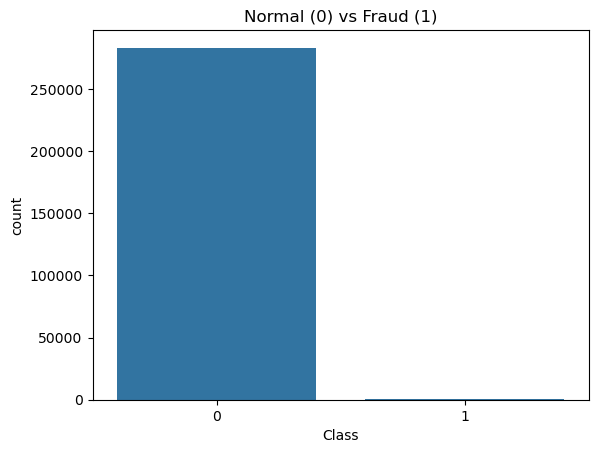

In [39]:
sns.countplot(x="Class", data=df)
plt.title("Normal (0) vs Fraud (1)")
plt.show()

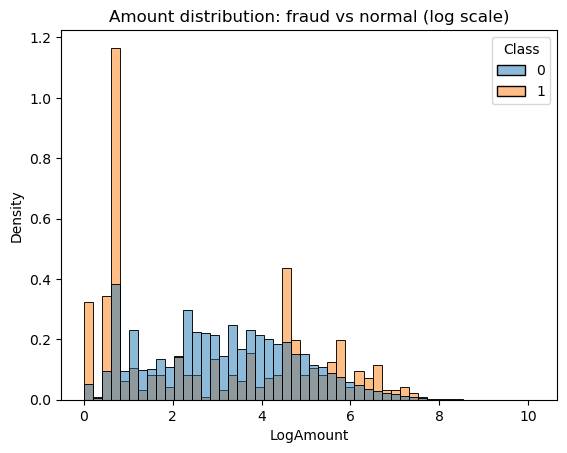

In [41]:
df["LogAmount"] = np.log1p(df["Amount"])

sns.histplot(data=df, x="LogAmount", hue="Class",
             stat="density", common_norm=False, bins=50)
plt.title("Amount distribution: fraud vs normal (log scale)")
plt.show()


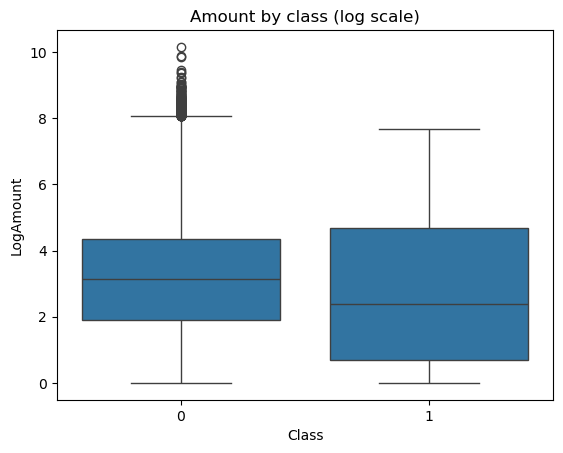

In [43]:
sns.boxplot(x="Class", y="LogAmount", data=df)
plt.title("Amount by class (log scale)")
plt.show()

# Correlations


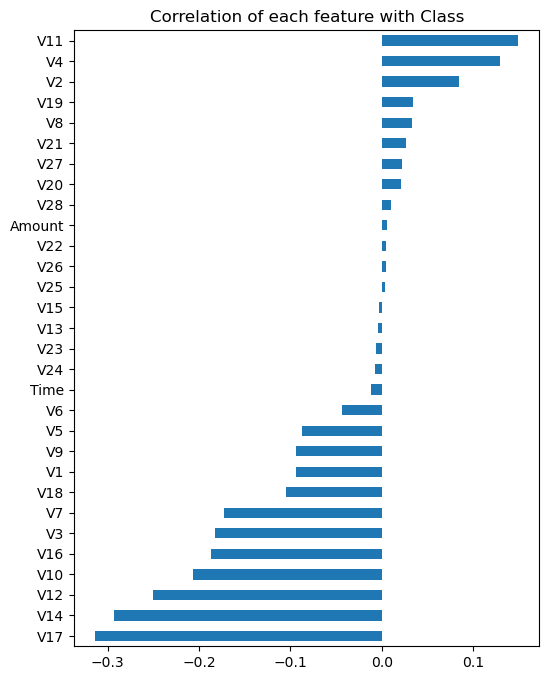

In [46]:
features= [f"V{i}" for i in range(1,29)] + ["Time","Amount"]
corr_with_class = df[features + ["Class"]].corr()["Class"].drop("Class").sort_values()
corr_with_class.plot(kind="barh",figsize=(6,8))
plt.title("Correlation of each feature with Class")
plt.show()

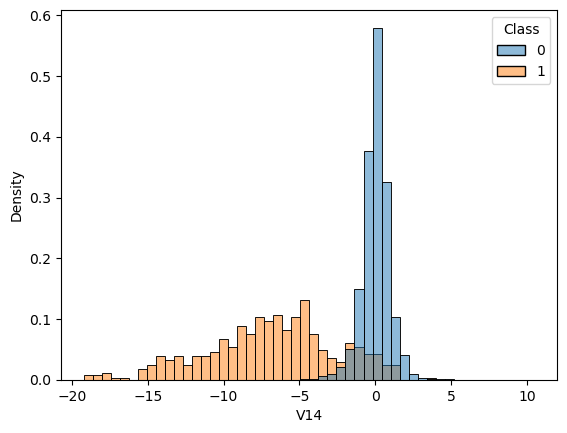

In [48]:
sns.histplot(data=df, x="V14", hue="Class", stat="density", common_norm=False, bins=50)
plt.show()

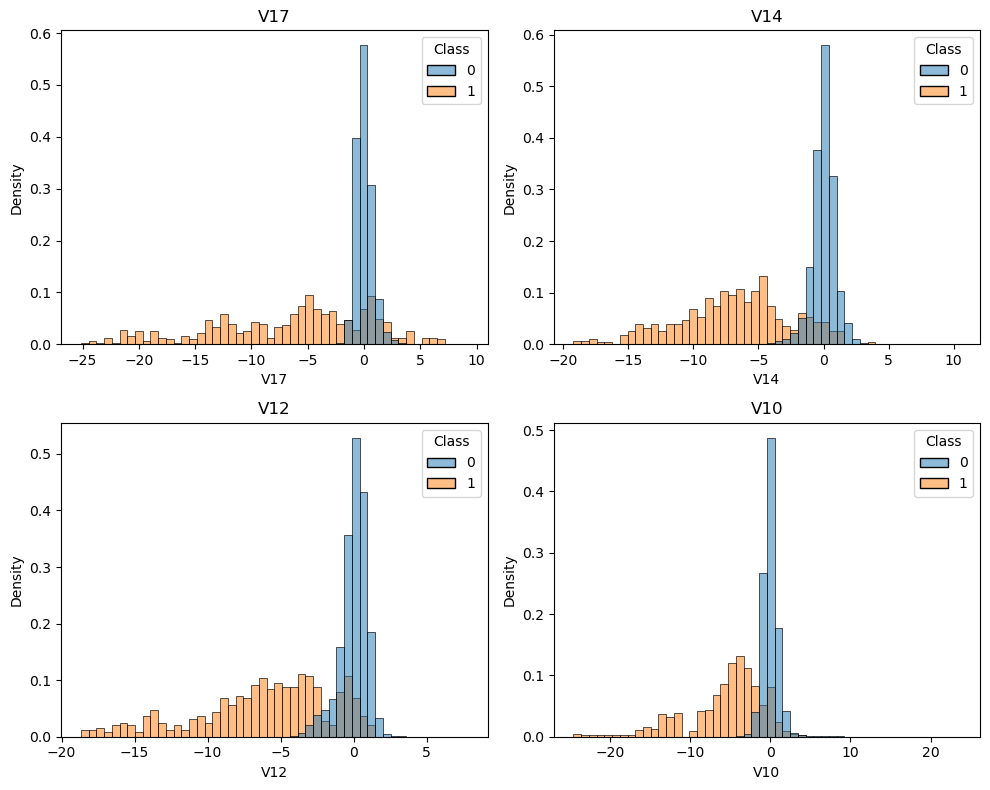

In [50]:
top = ["V17", "V14", "V12", "V10"]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, col in zip(axes.flatten(), top):
    sns.histplot(data=df, x=col, hue="Class", stat="density",
                 common_norm=False, bins=50, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

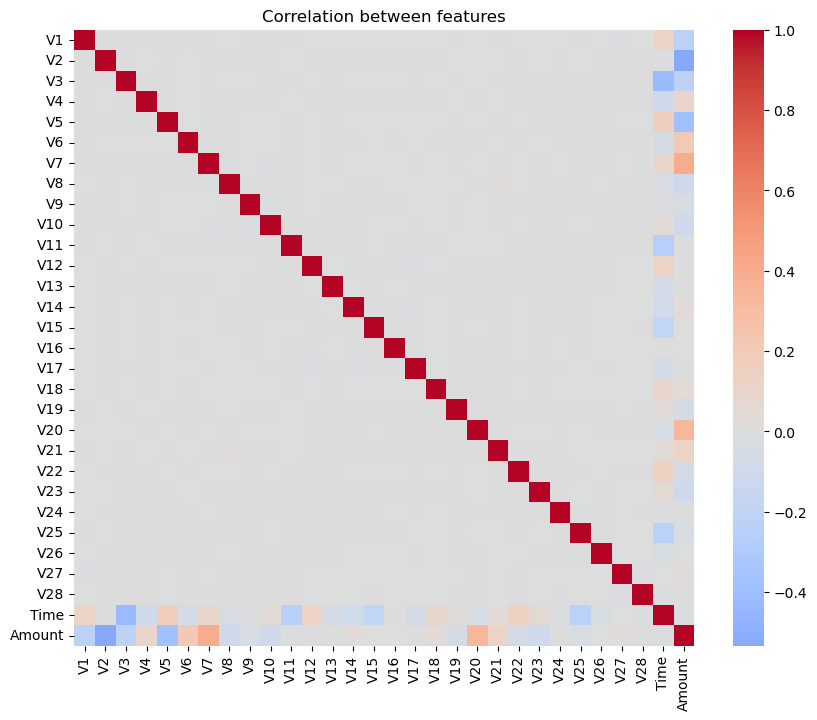

In [52]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[features].corr(), cmap="coolwarm", center=0)
plt.title("Correlation between features")
plt.show()

# NFDK